***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 上一节： [9.7 谱线数据处理](9_7_spectral_line_processing.ipynb)
    * 下一节： [9.9 偏振成像与 RM 入门](9_9_polarization_imaging.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 9.8 宽带与宽场高级成像：MFS、频谱指数与主波束校正

当带宽变宽、视场变大以后，成像就不再只是“把所有通道平均一下再 CLEAN”。至少有三件事会同时发生：

- 天体本身的亮度会随频率变化；
- 主波束会随频率收缩，因此离轴源会被额外染上一个假的频谱斜率；
- 一旦做主波束校正，图像边缘噪声会被同步放大。

因此宽带和宽场其实是耦合问题。真实软件里，这通常会把你带到 `MFS`、`MT-MFS`、`widebandpbcor`、`A-projection` 或 `AW-projection` 这些关键词上。

这一节不试图复刻工业级算法，而是用一个完全自包含的实验，把下面几件事讲透：

- 为什么简单 band average 会让离轴源的频谱被主波束污染；
- 为什么 `nterms > 1` 的 MFS 思想是有必要的；
- 为什么主波束校正会改善频谱，但同时放大图像边缘噪声；
- 为什么宽带/宽场成像的参数选择必须和科学目标一起考虑。


***


In [2]:
def normalized_gaussian(x, y, x0, y0, sigma_x, sigma_y):
    profile = np.exp(
        -0.5 * (((x - x0) / sigma_x) ** 2 + ((y - y0) / sigma_y) ** 2)
    )
    profile /= profile.sum()
    return profile


def make_restoring_beam(npix=72, sigma_pix=1.6):
    coords = np.arange(npix) - npix // 2
    xx, yy = np.meshgrid(coords, coords)
    beam = np.exp(-(xx**2 + yy**2) / (2.0 * sigma_pix**2))
    beam /= beam.max()
    return beam


def fft_convolve_same(image, kernel):
    image_ft = np.fft.fft2(image)
    kernel_ft = np.fft.fft2(np.fft.ifftshift(kernel))
    return np.real(np.fft.ifft2(image_ft * kernel_ft))


def primary_beam_gain(radius_arcsec, fwhm_arcsec):
    return np.exp(-4.0 * np.log(2.0) * (radius_arcsec / fwhm_arcsec) ** 2)


def aperture_mask(x, y, x0, y0, radius_arcsec):
    return ((x - x0) ** 2 + (y - y0) ** 2) <= radius_arcsec**2


def aperture_flux_spectrum(cube, mask, beam_area_pix):
    return np.nansum(cube[:, mask], axis=1) / beam_area_pix


def fit_powerlaw_spectrum(freqs_ghz, spectrum, ref_freq_ghz):
    x = np.log(freqs_ghz / ref_freq_ghz)
    y = np.log(spectrum)
    slope, intercept = np.polyfit(x, y, 1)
    model = np.exp(intercept) * (freqs_ghz / ref_freq_ghz) ** slope
    return np.exp(intercept), slope, model


def fit_powerlaw_map(cube, freqs_ghz, ref_freq_ghz, min_signal, valid_mask):
    i0_map = np.full(cube.shape[1:], np.nan, dtype=float)
    alpha_map = np.full_like(i0_map, np.nan)
    x = np.log(freqs_ghz / ref_freq_ghz)
    for iy in range(cube.shape[1]):
        for ix in range(cube.shape[2]):
            if not valid_mask[iy, ix]:
                continue
            spec = cube[:, iy, ix]
            if np.any(~np.isfinite(spec)) or np.any(spec <= min_signal):
                continue
            _, alpha, model = fit_powerlaw_spectrum(freqs_ghz, spec, ref_freq_ghz)
            alpha_map[iy, ix] = alpha
            i0_map[iy, ix] = model[np.argmin(np.abs(freqs_ghz - ref_freq_ghz))]
    return i0_map, alpha_map


def radius_at_pb_gain(radius_grid_arcsec, pb_profile, gain_level):
    valid = np.where(pb_profile >= gain_level)[0]
    if valid.size == 0:
        return 0.0
    return radius_grid_arcsec[valid[-1]]


npix = 72
cell_arcsec = 2.0
coords = (np.arange(npix) - npix // 2) * cell_arcsec
x_grid, y_grid = np.meshgrid(coords, coords)
radius_grid = np.sqrt(x_grid**2 + y_grid**2)

freqs_ghz = np.linspace(1.0, 2.0, 12)
ref_freq_ghz = np.median(freqs_ghz)
noise_std = 0.0015

sources = [
    {"name": "core", "flux_ref": 0.95, "alpha": -0.70, "x0": 0.0, "y0": 0.0, "sx": 3.0, "sy": 2.4},
    {"name": "steep_offaxis", "flux_ref": 0.55, "alpha": -1.15, "x0": 30.0, "y0": -18.0, "sx": 3.4, "sy": 2.2},
    {"name": "flat_knot", "flux_ref": 0.24, "alpha": 0.15, "x0": -24.0, "y0": 24.0, "sx": 2.4, "sy": 2.4},
    {"name": "ridge", "flux_ref": 0.32, "alpha": -0.40, "x0": 18.0, "y0": 26.0, "sx": 8.0, "sy": 3.0},
]

true_cube = np.zeros((freqs_ghz.size, npix, npix))
true_ref_image = np.zeros((npix, npix))
true_alpha_image = np.zeros((npix, npix))

for src in sources:
    profile = normalized_gaussian(
        x_grid, y_grid, src["x0"], src["y0"], src["sx"], src["sy"]
    )
    true_ref_image += src["flux_ref"] * profile
    true_alpha_image += src["alpha"] * profile / np.max(profile)
    for fi, freq in enumerate(freqs_ghz):
        true_cube[fi] += src["flux_ref"] * (freq / ref_freq_ghz) ** src["alpha"] * profile

restoring_beam = make_restoring_beam(npix=npix, sigma_pix=1.6)
beam_area_pix = restoring_beam.sum()

pb_fwhm_ref_arcsec = 96.0
pb_cube = np.zeros_like(true_cube)
true_cube_restored = np.zeros_like(true_cube)
observed_cube = np.zeros_like(true_cube)
for fi, freq in enumerate(freqs_ghz):
    pb_fwhm = pb_fwhm_ref_arcsec * (ref_freq_ghz / freq)
    pb_cube[fi] = primary_beam_gain(radius_grid, pb_fwhm)
    true_cube_restored[fi] = fft_convolve_same(true_cube[fi], restoring_beam)
    observed_cube[fi] = fft_convolve_same(true_cube[fi] * pb_cube[fi], restoring_beam)

observed_cube += noise_std * RNG.normal(size=observed_cube.shape)

pb_threshold = 0.28
cube_pbcor = np.where(pb_cube > pb_threshold, observed_cube / pb_cube, np.nan)
band_avg_obs = observed_cube.mean(axis=0)
ref_index = int(np.argmin(np.abs(freqs_ghz - ref_freq_ghz)))
true_ref_restored = true_cube_restored[ref_index]
band_avg_true = true_cube_restored.mean(axis=0)
valid_counts_pbcor = np.sum(np.isfinite(cube_pbcor), axis=0)
band_avg_pbcor = np.full_like(band_avg_obs, np.nan)
np.divide(
    np.nansum(cube_pbcor, axis=0),
    valid_counts_pbcor,
    out=band_avg_pbcor,
    where=valid_counts_pbcor > 0,
)

source_masks = {
    "core": aperture_mask(x_grid, y_grid, 0.0, 0.0, 8.0),
    "steep_offaxis": aperture_mask(x_grid, y_grid, 30.0, -18.0, 8.0),
    "flat_knot": aperture_mask(x_grid, y_grid, -24.0, 24.0, 7.0),
}

true_spec_off = aperture_flux_spectrum(
    true_cube_restored, source_masks["steep_offaxis"], beam_area_pix
)
obs_spec_off = aperture_flux_spectrum(observed_cube, source_masks["steep_offaxis"], beam_area_pix)
pbcor_spec_off = aperture_flux_spectrum(cube_pbcor, source_masks["steep_offaxis"], beam_area_pix)
band_flux_true_off = np.nansum(band_avg_true[source_masks["steep_offaxis"]]) / beam_area_pix
band_flux_obs_off = np.nansum(band_avg_obs[source_masks["steep_offaxis"]]) / beam_area_pix
band_flux_pbcor_off = np.nansum(band_avg_pbcor[source_masks["steep_offaxis"]]) / beam_area_pix


### 9.8.1 宽带和宽场为什么会耦合

若只看中心源，宽带成像似乎只是“多了一点频谱信息”；但一旦把视场拉大，主波束的频率依赖就会把离轴源额外压暗，并在人为制造一个偏陡的频谱斜率。

下面把三张图放在一起：

- 参考频率下的真实天空；
- 不做主波束校正、直接对所有通道平均的宽带图像；
- 先做主波束校正、再做带宽平均的图像。


若不受主波束影响，宽带平均后的离轴源积分通量 ≈ 0.475 Jy
未做 PB 校正的宽带平均积分通量 ≈ 0.339 Jy
做了 PB 校正后的宽带平均积分通量 ≈ 0.477 Jy


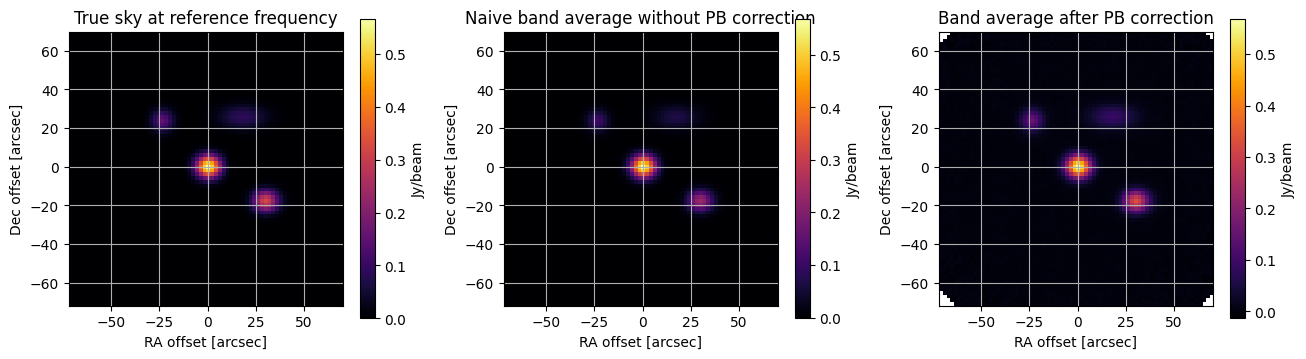

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.1))

for ax, image, title in [
    (axes[0], true_ref_restored, "True sky at reference frequency"),
    (axes[1], band_avg_obs, "Naive band average without PB correction"),
    (axes[2], band_avg_pbcor, "Band average after PB correction"),
]:
    im = ax.imshow(
        image,
        origin="lower",
        extent=[coords[0], coords[-1], coords[0], coords[-1]],
        cmap="inferno",
    )
    ax.set_title(title)
    ax.set_xlabel("RA offset [arcsec]")
    ax.set_ylabel("Dec offset [arcsec]")
    plt.colorbar(im, ax=ax, shrink=0.80, label="Jy/beam")

plt.tight_layout()
print(f"若不受主波束影响，宽带平均后的离轴源积分通量 ≈ {band_flux_true_off:.3f} Jy")
print(f"未做 PB 校正的宽带平均积分通量 ≈ {band_flux_obs_off:.3f} Jy")
print(f"做了 PB 校正后的宽带平均积分通量 ≈ {band_flux_pbcor_off:.3f} Jy")


这里最核心的判断是：**离轴源变暗并不一定意味着天体本身更陡，也可能只是主波束在高频端缩小了。** 这就是为什么宽带和宽场效应必须一起处理。


### 9.8.2 频变主波束会如何污染频谱指数

下面挑出一个离轴陡谱源，直接比较三条谱线：

- 真实频谱；
- 未做主波束校正时在图像域测得的频谱；
- 做了主波束校正后的频谱。

同时再画出中心和离轴位置的主波束增益随频率变化的趋势。这样能很直观地看到“假的谱指数”是怎么来的。


离轴源真实频谱指数 ≈ -1.15
未做 PB 校正时测得的频谱指数 ≈ -1.86
做了 PB 校正后的频谱指数 ≈ -1.14


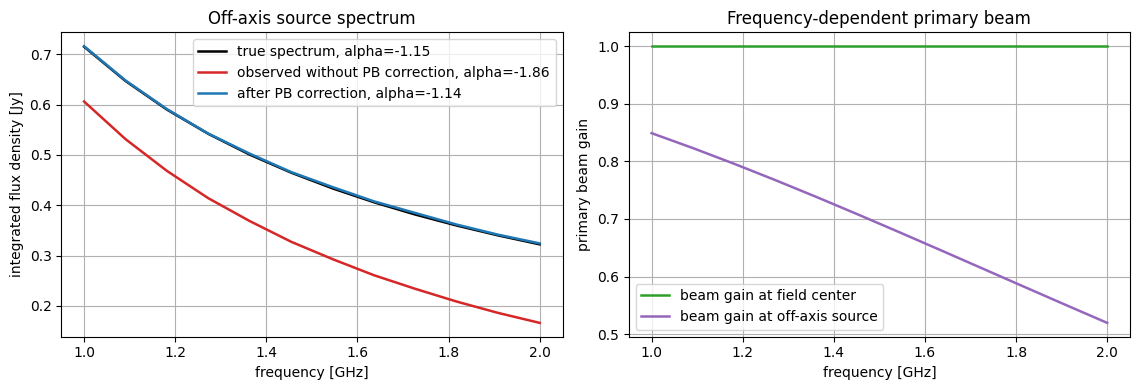

In [4]:
_, alpha_true_off, model_true_off = fit_powerlaw_spectrum(
    freqs_ghz, true_spec_off, ref_freq_ghz
)
_, alpha_obs_off, model_obs_off = fit_powerlaw_spectrum(
    freqs_ghz, np.clip(obs_spec_off, 1e-6, None), ref_freq_ghz
)
_, alpha_pbcor_off, model_pbcor_off = fit_powerlaw_spectrum(
    freqs_ghz, np.clip(pbcor_spec_off, 1e-6, None), ref_freq_ghz
)

center_gain = np.array([pb_cube[fi, npix // 2, npix // 2] for fi in range(freqs_ghz.size)])
offaxis_gain = np.array([
    pb_cube[fi, np.argmin(np.abs(coords - (-18.0))), np.argmin(np.abs(coords - 30.0))]
    for fi in range(freqs_ghz.size)
])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))

axes[0].plot(freqs_ghz, true_spec_off, color="black", lw=1.8, label=f"true spectrum, alpha={alpha_true_off:.2f}")
axes[0].plot(freqs_ghz, obs_spec_off, color="tab:red", lw=1.8, label=f"observed without PB correction, alpha={alpha_obs_off:.2f}")
axes[0].plot(freqs_ghz, pbcor_spec_off, color="tab:blue", lw=1.8, label=f"after PB correction, alpha={alpha_pbcor_off:.2f}")
axes[0].set_xlabel("frequency [GHz]")
axes[0].set_ylabel("integrated flux density [Jy]")
axes[0].set_title("Off-axis source spectrum")
axes[0].legend(loc="upper right")

axes[1].plot(freqs_ghz, center_gain, color="tab:green", lw=1.8, label="beam gain at field center")
axes[1].plot(freqs_ghz, offaxis_gain, color="tab:purple", lw=1.8, label="beam gain at off-axis source")
axes[1].set_xlabel("frequency [GHz]")
axes[1].set_ylabel("primary beam gain")
axes[1].set_title("Frequency-dependent primary beam")
axes[1].legend(loc="lower left")

plt.tight_layout()
print(f"离轴源真实频谱指数 ≈ {alpha_true_off:.2f}")
print(f"未做 PB 校正时测得的频谱指数 ≈ {alpha_obs_off:.2f}")
print(f"做了 PB 校正后的频谱指数 ≈ {alpha_pbcor_off:.2f}")


这个实验基本就说明了 `widebandpbcor` 这类步骤存在的必要性：如果不先把主波束的频率依赖剥掉，你测到的“谱指数”里会混进明显的仪器项。


### 9.8.3 用简化的 `nterms=2` 思想恢复参考频率亮度和谱指数

`MT-MFS` 的核心精神，是在宽带数据里同时解出“参考频率亮度”和“频谱变化项”。下面不复刻完整算法，只做一个简化版的逐像素幂律拟合：

- 对未做主波束校正的 cube 拟合一个表观谱指数图；
- 对做了主波束校正的 cube 再拟合一次；
- 比较不同源位置的谱指数恢复结果。


core 真实 alpha = -0.70，未校正图像域估计 = -0.71，PB 校正后估计 = -0.69
steep_offaxis 真实 alpha = -1.15，未校正图像域估计 = -1.87，PB 校正后估计 = -1.14
flat_knot 真实 alpha = +0.15，未校正图像域估计 = -0.52，PB 校正后估计 = +0.16


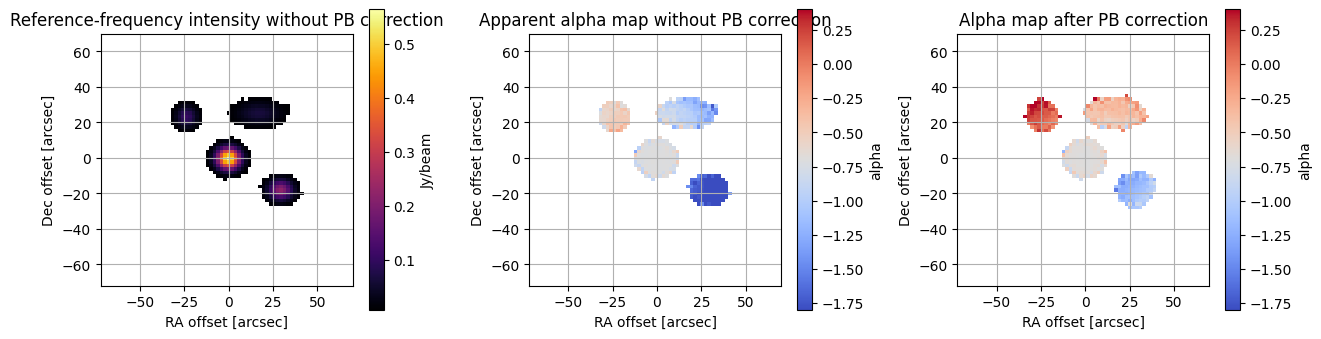

In [5]:
valid_mask_obs = np.nanmax(observed_cube, axis=0) > (6.0 * noise_std)
cube_pbcor_finite_max = np.max(
    np.where(np.isfinite(cube_pbcor), cube_pbcor, -np.inf), axis=0
)
valid_mask_pbcor = (
    np.all(pb_cube > 0.35, axis=0)
    & np.isfinite(cube_pbcor_finite_max)
    & (cube_pbcor_finite_max > (6.0 * noise_std))
)

i0_obs, alpha_map_obs = fit_powerlaw_map(
    np.clip(observed_cube, 1e-6, None),
    freqs_ghz,
    ref_freq_ghz,
    min_signal=2.5 * noise_std,
    valid_mask=valid_mask_obs,
)
i0_pbcor, alpha_map_pbcor = fit_powerlaw_map(
    cube_pbcor,
    freqs_ghz,
    ref_freq_ghz,
    min_signal=2.5 * noise_std,
    valid_mask=valid_mask_pbcor,
)

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.1))

im0 = axes[0].imshow(
    i0_obs,
    origin="lower",
    extent=[coords[0], coords[-1], coords[0], coords[-1]],
    cmap="inferno",
)
axes[0].set_title("Reference-frequency intensity without PB correction")
axes[0].set_xlabel("RA offset [arcsec]")
axes[0].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im0, ax=axes[0], shrink=0.80, label="Jy/beam")

im1 = axes[1].imshow(
    alpha_map_obs,
    origin="lower",
    extent=[coords[0], coords[-1], coords[0], coords[-1]],
    cmap="coolwarm",
    vmin=-1.8,
    vmax=0.4,
)
axes[1].set_title("Apparent alpha map without PB correction")
axes[1].set_xlabel("RA offset [arcsec]")
axes[1].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im1, ax=axes[1], shrink=0.80, label="alpha")

im2 = axes[2].imshow(
    alpha_map_pbcor,
    origin="lower",
    extent=[coords[0], coords[-1], coords[0], coords[-1]],
    cmap="coolwarm",
    vmin=-1.8,
    vmax=0.4,
)
axes[2].set_title("Alpha map after PB correction")
axes[2].set_xlabel("RA offset [arcsec]")
axes[2].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im2, ax=axes[2], shrink=0.80, label="alpha")

plt.tight_layout()

source_truth = {"core": -0.70, "steep_offaxis": -1.15, "flat_knot": 0.15}
for name, truth in source_truth.items():
    est_obs = np.nanmean(alpha_map_obs[source_masks[name]])
    est_pb = np.nanmean(alpha_map_pbcor[source_masks[name]])
    print(f"{name} 真实 alpha = {truth:+.2f}，未校正图像域估计 = {est_obs:+.2f}，PB 校正后估计 = {est_pb:+.2f}")


这个练习对应的正是现代宽带成像里 `nterms=2` 或 `nterms=3` 的基本动机：**不仅要成像，还要把频谱项一起恢复出来。** 如果只做单频近似，宽带数据里的信息会被浪费掉，甚至被主波束污染。


### 9.8.4 主波束校正会把边缘噪声一起放大

主波束校正几乎总是必要的，但它不是免费的。因为你在除以主波束增益时，也同时在除以噪声。

下面用一个径向剖面把这个代价画出来：参考频率下的主波束增益、以及做主波束校正后噪声随视场半径增长的趋势。


参考频率下 PB=0.50 的视场半径约为 48.0 arcsec
参考频率下 PB=0.25 的视场半径约为 67.7 arcsec
若把参考频率下的图像边缘推进到 PB=0.25，等效噪声会放大到中心的 3.96 倍


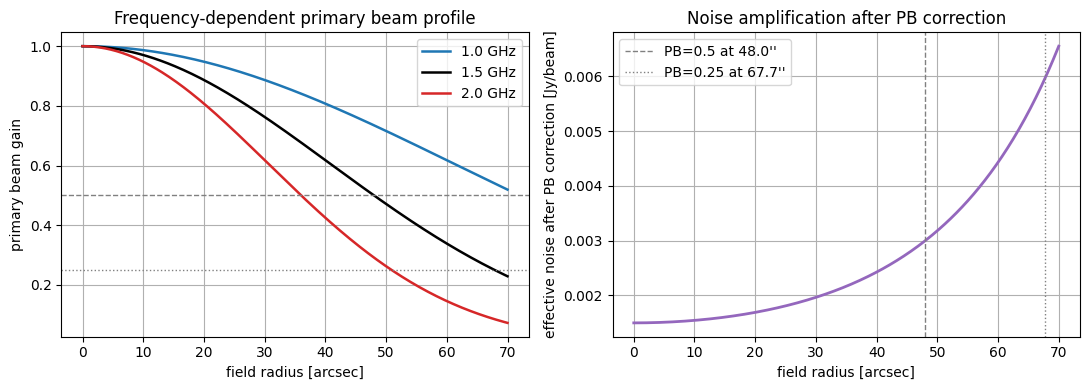

In [6]:
radius_arcsec = np.linspace(0.0, 70.0, 300)
pb_profile_ref = primary_beam_gain(radius_arcsec, pb_fwhm_ref_arcsec)
pb_profile_low = primary_beam_gain(radius_arcsec, pb_fwhm_ref_arcsec * (ref_freq_ghz / freqs_ghz[0]))
pb_profile_high = primary_beam_gain(radius_arcsec, pb_fwhm_ref_arcsec * (ref_freq_ghz / freqs_ghz[-1]))
corrected_noise_ref = noise_std / np.maximum(pb_profile_ref, 1e-3)

radius_pb50 = radius_at_pb_gain(radius_arcsec, pb_profile_ref, 0.50)
radius_pb25 = radius_at_pb_gain(radius_arcsec, pb_profile_ref, 0.25)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

axes[0].plot(radius_arcsec, pb_profile_low, color="tab:blue", lw=1.8, label=f"{freqs_ghz[0]:.1f} GHz")
axes[0].plot(radius_arcsec, pb_profile_ref, color="black", lw=1.8, label=f"{ref_freq_ghz:.1f} GHz")
axes[0].plot(radius_arcsec, pb_profile_high, color="tab:red", lw=1.8, label=f"{freqs_ghz[-1]:.1f} GHz")
axes[0].axhline(0.5, color="gray", ls="--", lw=1.0)
axes[0].axhline(0.25, color="gray", ls=":", lw=1.0)
axes[0].set_xlabel("field radius [arcsec]")
axes[0].set_ylabel("primary beam gain")
axes[0].set_title("Frequency-dependent primary beam profile")
axes[0].legend(loc="upper right")

axes[1].plot(radius_arcsec, corrected_noise_ref, color="tab:purple", lw=2.0)
axes[1].axvline(radius_pb50, color="gray", ls="--", lw=1.0, label=f"PB=0.5 at {radius_pb50:.1f}''")
axes[1].axvline(radius_pb25, color="gray", ls=":", lw=1.0, label=f"PB=0.25 at {radius_pb25:.1f}''")
axes[1].set_xlabel("field radius [arcsec]")
axes[1].set_ylabel("effective noise after PB correction [Jy/beam]")
axes[1].set_title("Noise amplification after PB correction")
axes[1].legend(loc="upper left")

plt.tight_layout()
print(f"参考频率下 PB=0.50 的视场半径约为 {radius_pb50:.1f} arcsec")
print(f"参考频率下 PB=0.25 的视场半径约为 {radius_pb25:.1f} arcsec")
print(
    f"若把参考频率下的图像边缘推进到 PB=0.25，等效噪声会放大到中心的 "
    f"{corrected_noise_ref[np.argmin(np.abs(radius_arcsec - radius_pb25))] / noise_std:.2f} 倍"
)


这就是为什么真实数据处理中常常需要同时指定：

- 成像视场多大；
- 主波束校正做到什么 cutoff；
- 最终科学分析只在什么半径内报告结果。

如果科学目标是离轴微弱源或频谱指数图，那么这些参数不能靠“默认值”处理。


### 9.8.5 与真实软件流程的对应

若把这个教学实验映射到真实软件环境，最常见的工作流大致是：

- `tclean` + `specmode='mfs'`：做宽带连续谱成像；
- `nterms=2/3`：让成像同时解参考频率亮度和频谱项；
- `widebandpbcor` 或等价步骤：校正主波束引入的频谱偏差；
- `wprojplanes`、`A-projection`、`AW-projection`：在更宽场、更高动态范围情形下处理方向相关效应；
- 参数选择：把 `cell`、`imsize`、`pb cutoff`、`nterms` 和科学目标联动起来。

这个 notebook 依然只是简化版，但它想传达的专业判断已经很明确：**宽带频谱、主波束和宽场效应是同一个问题族，而不是三个彼此独立的小修饰项。**
